In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import optuna
import tensorflow as tf

import warnings

In [47]:
df = pd.read_csv('../data/CORCCACBS.csv')


a = df.groupby(df['date'])['value'].mean().round(2)#.reset_index()
b = pd.to_datetime(df['date'].unique())
df= pd.DataFrame({
    'date':b,
    'value':a.values
})
df = df.set_index('date')


def traintestsplit(df):
    train = df.loc[:'2015']
    val = df.loc['2016':'2019']
    test = df.loc['2020':]

    return train,val ,test

train_set, val_set, test_set = traintestsplit(df)

Creating our timeseries data set via Tensorflow

GradDescent requires IID, shuffling training windows (not the contents)
- so the model's weight doesn't update / get biased toward whatever pattern is most recent!

In [48]:
seq_length = 8

train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    train_set,targets = train_set[seq_length:],#targets are 3 steps into the future
    sequence_length=seq_length, batch_size=4,shuffle = True, seed=11
    )

val_dataset = tf.keras.utils.timeseries_dataset_from_array(
    val_set, targets=val_set[seq_length:], sequence_length=seq_length, batch_size=4, shuffle= True, seed=11
)

test_dataset = tf.keras.utils.timeseries_dataset_from_array(
    test_set, targets=test_set[seq_length:], sequence_length=seq_length, batch_size=4,shuffle= True, seed=11
)

Trying a basic linear model first: Using Huber Loss

In [49]:
tf.random.set_seed(11)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=[seq_length])
])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_mae',
                                                     patience=50,
                                                     restore_best_weights=True)

opt = tf.keras.optimizers.SGD(learning_rate=.02,momentum=0.9)


model.compile(loss=tf.keras.losses.Huber(),optimizer=opt,metrics=['mae'])


history = model.fit(train_dataset, validation_data=val_dataset, epochs=500,
                    callbacks=[early_stopping_cb])

Epoch 1/500


c:\Users\Marwa\anaconda3\envs\cc_abs\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.6464 - mae: 6.1348 - val_loss: 2.5319 - val_mae: 3.0319
Epoch 2/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7099 - mae: 2.1357 - val_loss: 0.4731 - val_mae: 0.9666
Epoch 3/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5003 - mae: 1.9503 - val_loss: 2.1668 - val_mae: 2.6668
Epoch 4/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.2316 - mae: 4.7201 - val_loss: 2.1925 - val_mae: 2.6925
Epoch 5/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6566 - mae: 3.1162 - val_loss: 1.5526 - val_mae: 2.0526
Epoch 6/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4547 - mae: 2.9276 - val_loss: 2.6915 - val_mae: 3.1915
Epoch 7/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1651 - mae: 1.5974 - val_loss: 1.5324 - val_mae: 2.0324
Epoch 8/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3716 - mae: 2.8525 - val_loss: 2.7678 - val_mae: 3.2678
Epoch 9/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.1187 - mae: 4.

Best epoch: 58, Val MAE: 0.0625


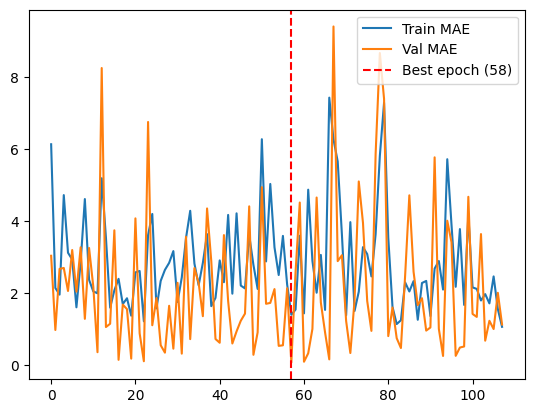

In [51]:
import matplotlib.pyplot as plt

best_val_mae = min(history.history['val_mae'])
best_epoch = history.history['val_mae'].index(best_val_mae) + 1  # +1 since epochs start at 1
print(f"Best epoch: {best_epoch}, Val MAE: {best_val_mae:.4f}")

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.legend()
plt.show()